In [2]:

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sb
warnings.filterwarnings('ignore')

In [3]:
X_train = pd.read_csv('../data/processed/Xtrain.csv')
Y_train = pd.read_csv('../data/processed/Ytrain.csv')
X_test = pd.read_csv('../data/processed/Xtest.csv')
Y_test = pd.read_csv('../data/processed/Ytest.csv')

# 7. Modelos De Clasificación 
 - RegLogistica
 - K vecinos más cercanos 
 - Naive bayes
 - Máquinas de soporte vectorial 
 - Arboles de decisión 
 - Random Forest 
 - Adaptative boosting 
 - Gradient boosting 
 - Redes Neuronales percepción multicapa 

 **Busqueda de híperparametros con validación cruzada**
 Queremos evitar el sobreajuste  
 Los modelos pueden estar en tres estados  
 - Ajustado
    - Cuando el desempeño de entrenamiento y validaión son similares y cercanos a 1 (acuraccy)
 - SubAjustado
   -  Cuando el desempeño de entrenamiento y validaión son similares y cercanos a 0
 - SobreAjustado
    -  Cuando el desempeño de entrenamiento es mucho mayor que el de validaión, (20%)  

**El desempeño de clasificación**
- Matriz de confusión  (VP, VN, FP, FN)
  0: positivo, 1: negativo
  VN + VP >> FP + FN  
- Accuracy: Verdades totales / Total
- Precisión: VP / VP + FN :  Vp en relación a los falsos negativos 
- Recall: VP / VP + FP:  Vp en relación a los falsos positivos

### RegLogistica
Tomamos una estimación lineal    
se mete en un humbral duro (función logistica)   
Se clasifican según la condición en dos grupos   
- El objetivo es encontrar los valores de alphai que minimicen el error de pronostico 
- Debemos hacer un proceso iterativo para encontrar un valor de error minimo para que alpha se acerque más al minimo global de costo
- Beta es la taza de aprenizaje, este es un valor real positivo, representa el tamaño del paso de estimación en cada iteración 
- Beta es el HÍPERPARAMETRO de la REGLOGISTICA

##### Metodos de busqueda de hiperparametros ####
**Exaustiva:** Crea tantos modelos como posibles combinaciones de los parametros y los ajusta todos (ácida mejor por exaustiva)
- La cantidad de modelos = * hiperparametros   

**Aleatoria:** Crea una muestra random de todos los posibles modelos construidos por la combinación de los hiperparametros (mejor por la velocidad mayor error)

**Busqueda con validación cruzada:**  
Parte Xtrain Ytrain en cierta cantidad de "folds" tendría que hacer la misma cantidad de experimentos que de folds donde se  
hacen combinaciones diferentes de los folds para cada experimento deben ser menos de 10 particiones o folds 
Con los folds minimizamos el sobreajuste, dentro del mismo entrenamiento se hacen validaciones 
Se eligen todos menos un fold para entrenar y verificamos con el restante, así hasta iterar todos, esto mejora el modelo 

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # metodos de busqueda de hiperparametros con validacion cruzada

In [5]:
from sklearn.linear_model import LogisticRegression

# dejaremos saga como el metodo para encotnrar la gradiente ya que nos deja

model1 = LogisticRegression(solver = 'saga', random_state=123)
#si el mejor da en los limites debemos ampliar el rango, si están dos muy iguales investigamos ese rango
param_grid = {'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]} 

clf_1 = GridSearchCV(estimator=model1, param_grid=param_grid, cv=5, scoring='accuracy') #cv: debe ser impar entero, f1 tiene en cuenta el acuracy y recall
clf_1.fit(X_train, Y_train)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [0.0001, 0.001, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


**Clasificacion multiclase**
- Uno vs uno:
- Uno vs todos:   

In [6]:
validacion = pd.concat([pd.DataFrame(clf_1.cv_results_['params']),
                        pd.DataFrame(clf_1.cv_results_['mean_test_score'], columns=['accuracy'])], axis=1)
validacion.sort_values(by='accuracy', ascending=False)

,C,penalty,accuracy
18,100.0000,l1,0.946857
21,1000.0000,l1,0.946670
22,1000.0000,l2,0.946484
15,10.0000,l1,0.946111
19,100.0000,l2,0.945924
16,10.0000,l2,0.942941
12,1.0000,l1,0.940330
9,0.1000,l1,0.927838
13,1.0000,l2,0.921869
10,0.1000,l2,0.877305


In [7]:
modelo_1_final= clf_1.best_estimator_
modelo_1_final

,penalty,'l1'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


              precision    recall  f1-score   support

        High       0.99      0.97      0.98      1768
         Low       0.92      0.96      0.94      1789
      Medium       0.93      0.91      0.92      1806

    accuracy                           0.95      5363
   macro avg       0.95      0.95      0.95      5363
weighted avg       0.95      0.95      0.95      5363

[[1722    0   46]
 [   0 1714   75]
 [  13  151 1642]]


<Axes: >

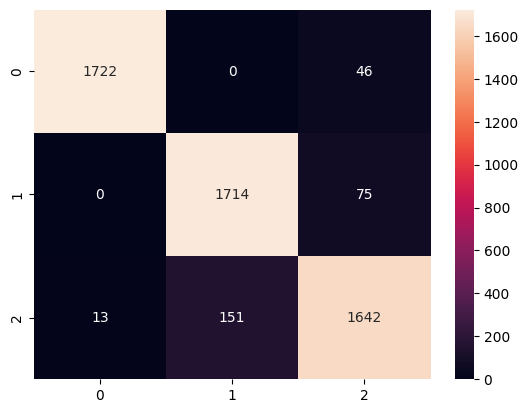

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_1_train = modelo_1_final.predict(X_train)


print(classification_report(Y_train, y_pred_1_train))
print(confusion_matrix(Y_train, y_pred_1_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_1_train), annot=True, fmt='d')


              precision    recall  f1-score   support

        High       0.99      0.96      0.98       786
         Low       0.92      0.97      0.94       765
      Medium       0.93      0.90      0.91       748

    accuracy                           0.94      2299
   macro avg       0.94      0.94      0.94      2299
weighted avg       0.94      0.94      0.94      2299

[[758   0  28]
 [  0 739  26]
 [  7  68 673]]


<Axes: >

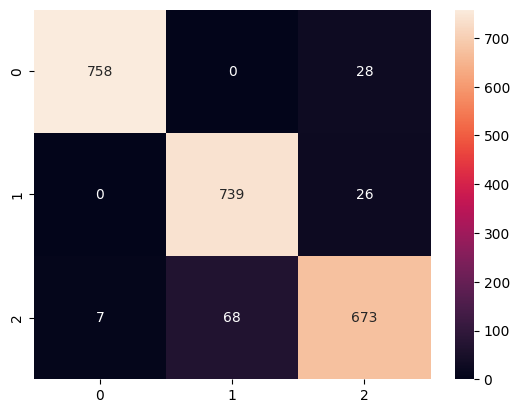

In [9]:
y_pred_1_test = modelo_1_final.predict(X_test)

print(classification_report(Y_test, y_pred_1_test))
print(confusion_matrix(Y_test, y_pred_1_test))
sb.heatmap(confusion_matrix(Y_test, y_pred_1_test), annot=True, fmt='d')

# columnas prediccion, filas real 

### k-vecinos más cercanos 
- K: Cantidad de vecinos (tiene que ser impar)
- Distancica: Euclidicana o Manhatan

Asociarse a los k vecinos donde la distancia sea mínima 
K es un entero positivo 

In [10]:
from sklearn.neighbors import KNeighborsClassifier

modelo_2 = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 19, 21, 53], 'p': [1, 2]} # 1 es manhattan y 2 es euclidiana
clf_2 = GridSearchCV(modelo_2, param_grid, cv=5, scoring='f1_weighted')
clf_2.fit(X_train, Y_train)


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [11]:
validacion = pd.concat([pd.DataFrame(clf_2.cv_results_['params']),
                        pd.DataFrame(clf_2.cv_results_['mean_test_score'], columns=['f1_weighted'])], axis=1)
validacion.sort_values(by='f1_weighted', ascending=False)

,n_neighbors,p,f1_weighted
0,3,1,0.876216
1,3,2,0.867592
2,5,1,0.830375
3,5,2,0.820943
4,7,1,0.800034
5,7,2,0.777167
6,19,1,0.749811
8,21,1,0.741990
7,19,2,0.712756
9,21,2,0.704385


In [12]:
modelo_2_final = clf_2.best_estimator_
modelo_2_final

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


              precision    recall  f1-score   support

        High       0.99      0.86      0.92      1768
         Low       0.99      1.00      0.99      1789
      Medium       0.89      0.99      0.94      1806

    accuracy                           0.95      5363
   macro avg       0.96      0.95      0.95      5363
weighted avg       0.96      0.95      0.95      5363

[[1525   19  224]
 [   0 1789    0]
 [  17    1 1788]]


<Axes: >

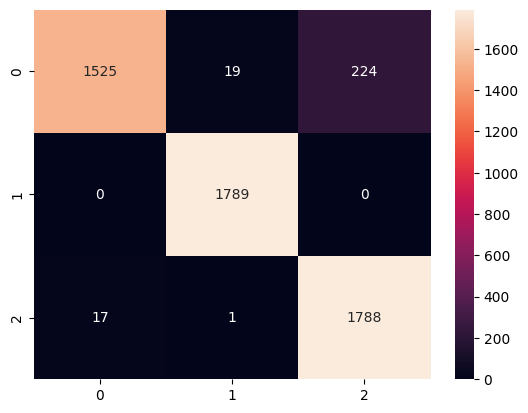

In [13]:
y_pred_2_train = modelo_2_final.predict(X_train)

print(classification_report(Y_train, y_pred_2_train))
print(confusion_matrix(Y_train, y_pred_2_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_2_train), annot=True, fmt='d')


              precision    recall  f1-score   support

        High       0.94      0.75      0.83       786
         Low       0.98      1.00      0.99       765
      Medium       0.80      0.94      0.86       748

    accuracy                           0.90      2299
   macro avg       0.90      0.90      0.89      2299
weighted avg       0.90      0.90      0.89      2299

[[588  16 182]
 [  0 765   0]
 [ 40   2 706]]


<Axes: >

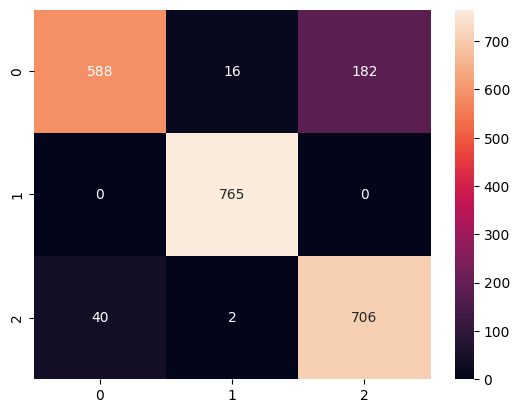

In [14]:
y_pred_2_test = modelo_2_final.predict(X_test)

print(classification_report(Y_test, y_pred_2_test))
print(confusion_matrix(Y_test, y_pred_2_test))
sb.heatmap(confusion_matrix(Y_test, y_pred_2_test), annot=True, fmt='d')

### Máquinas de soporte vectorial 

Traza una linea recta de separación de las clases, sobre esta linea se tiene un rango donde puede haber error
Es un modelo para problemas lineales, si no lo son, como comunmente pasa se debe hacer una transformación lineal para crear  
una nueva dim y poder crear una linea que si separe los datos correctamente -> KERNEL

Hiperparametros:
- C: real positivo, determina que tan grande es el rango de error (Eb)  
   Cuando tiende a 0 hay menor penalización al error   
   Cuando tiende a infinito hay mayor penalización, puede causar sobreajuste 

- KERNELS:  
   polynomial  1,2,3,4,5....
   gaussiano radial  
   laplaciano   
   Thin-plate spline (log)  
   Sigmoid (tanH)  



In [15]:
from sklearn.svm import SVC

modelo_3 = SVC(random_state= 123)

param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
              'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
              'degree': [2, 3, 4]}

clf_3 = GridSearchCV(estimator=modelo_3, param_grid=param_grid, cv=5, scoring='f1_weighted')
clf_3.fit(X_train, Y_train)

KeyboardInterrupt: 

In [ ]:
validation = pd.concat([pd.DataFrame(clf_3.cv_results_['params']),
                        pd.DataFrame(clf_3.cv_results_['mean_test_score'], columns=['f1_weighted'])], axis=1)
validation.sort_values(by='f1_weighted', ascending=False)

,C,degree,kernel,f1_weighted
50,10.000,2,poly,0.989368
62,100.000,2,poly,0.989181
53,10.000,3,rbf,0.989175
49,10.000,2,rbf,0.989175
57,10.000,4,rbf,0.989175
...,...,...,...,...
3,0.001,2,sigmoid,0.169668
1,0.001,2,rbf,0.169668
5,0.001,3,rbf,0.169668
9,0.001,4,rbf,0.169668


In [ ]:
modelo_3_final = clf_3.best_estimator_
modelo_3_final

,C,10.0
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1768
         Low       1.00      1.00      1.00      1789
      Medium       1.00      1.00      1.00      1806

    accuracy                           1.00      5363
   macro avg       1.00      1.00      1.00      5363
weighted avg       1.00      1.00      1.00      5363

[[1767    0    1]
 [   0 1789    0]
 [   0    0 1806]]


<Axes: >

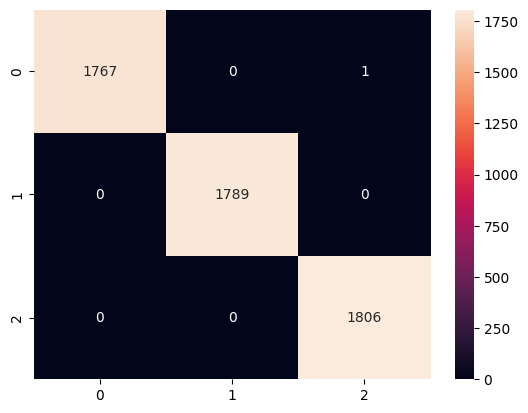

In [ ]:
y_pred_3_train = modelo_3_final.predict(X_train)

print(classification_report(Y_train, y_pred_3_train))
print(confusion_matrix(Y_train, y_pred_3_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_3_train), annot=True, fmt='d')


              precision    recall  f1-score   support

        High       1.00      0.97      0.98       786
         Low       1.00      1.00      1.00       765
      Medium       0.97      1.00      0.98       748

    accuracy                           0.99      2299
   macro avg       0.99      0.99      0.99      2299
weighted avg       0.99      0.99      0.99      2299

[[760   0  26]
 [  0 765   0]
 [  0   0 748]]


<Axes: >

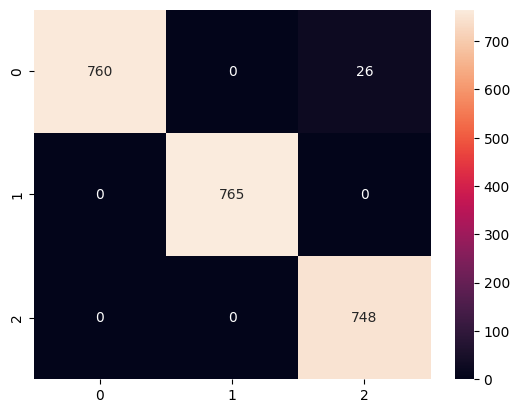

In [ ]:
y_pred_3_test = modelo_3_final.predict(X_test)

print(classification_report(Y_test, y_pred_3_test))
print(confusion_matrix(Y_test, y_pred_3_test))
sb.heatmap(confusion_matrix(Y_test, y_pred_3_test), annot=True, fmt='d')


### Arboles de Decisión

Solamente ramifica en 2 ramas, se crean arboles puros, sus hojas cuentan con idividuos de una misma clase 
El proceso es de minimización de la probabilidad de que un individuo sea de otra clase 
En cada nodo se analiza una variable

Se basa en cada nodo en una función de impureza  
Pmk: La proporción de los individuos clase k en el nodo  

HIPERPARAMETROS:  
- Impureza:  
  Tasa de error max (Em) -> queremos que sea 0  (1-Pmk)  
  Genie (Gm) Es la sum del producto de exito o rechazo -> se espera que sea 0  (Pmk * (1 - Pmk))  
  Entropía (Dm) (Pmk * Log(Pmk))  
- Cantidad de hojas 





In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

modelo_4 = DecisionTreeClassifier(random_state=123)

param_grid = {'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': [None, 5, 10, 20],
              'min_samples_split': [2, 3, 4], # 
              'max_leaf_nodes': [None, 10, 20, 50]}

clf_4 = GridSearchCV(estimator=modelo_4, param_grid=param_grid, cv=3, scoring='f1_weighted') # cv tiene que ver con la complegidad 
clf_4.fit(X_train, Y_train) 

,estimator,DecisionTreeC...dom_state=123)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 5, ...], 'max_leaf_nodes': [None, 10, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [17]:
validation = pd.concat([pd.DataFrame(clf_4.cv_results_['params']),
                        pd.DataFrame(clf_4.cv_results_['mean_test_score'], columns=['f1_weighted'])], axis=1)
validation.sort_values(by='f1_weighted', ascending=False)

,criterion,max_depth,max_leaf_nodes,min_samples_split,f1_weighted
84,entropy,20.0,NaN,2,0.963169
96,log_loss,NaN,NaN,2,0.963169
132,log_loss,20.0,NaN,2,0.963169
48,entropy,NaN,NaN,2,0.963169
133,log_loss,20.0,NaN,3,0.962985
...,...,...,...,...,...
65,entropy,5.0,10.0,4,0.755935
64,entropy,5.0,10.0,3,0.755935
111,log_loss,5.0,10.0,2,0.755935
112,log_loss,5.0,10.0,3,0.755935


In [18]:
modelo_4_final = clf_4.best_estimator_
modelo_4_final

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1768
         Low       1.00      1.00      1.00      1789
      Medium       1.00      1.00      1.00      1806

    accuracy                           1.00      5363
   macro avg       1.00      1.00      1.00      5363
weighted avg       1.00      1.00      1.00      5363

[[1768    0    0]
 [   0 1789    0]
 [   0    0 1806]]


<Axes: >

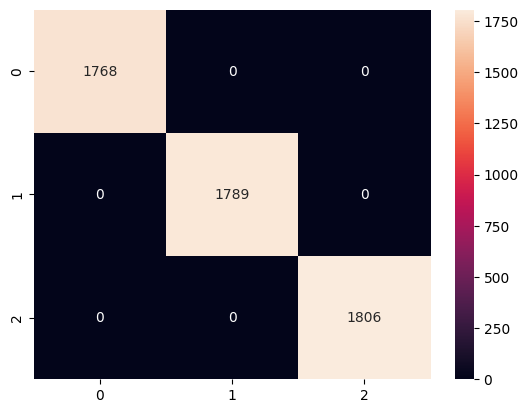

In [19]:
y_pred_4_train = modelo_4_final.predict(X_train)

print(classification_report(Y_train, y_pred_4_train))
print(confusion_matrix(Y_train, y_pred_4_train))
sb.heatmap(confusion_matrix(Y_train, y_pred_4_train), annot=True, fmt='d')

              precision    recall  f1-score   support

        High       0.99      0.93      0.96       786
         Low       1.00      1.00      1.00       765
      Medium       0.94      0.99      0.96       748

    accuracy                           0.98      2299
   macro avg       0.98      0.98      0.98      2299
weighted avg       0.98      0.98      0.98      2299

[[733   2  51]
 [  0 765   0]
 [  4   0 744]]


<Axes: >

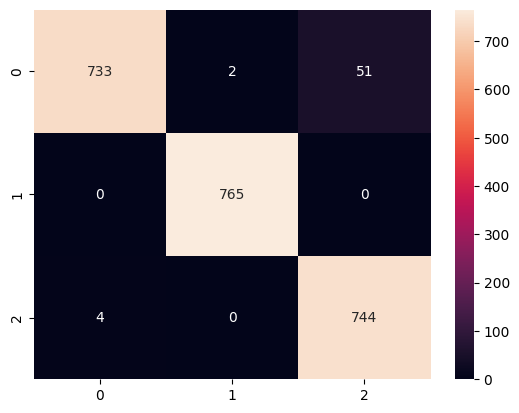

In [20]:
y_pred_4_test = modelo_4_final.predict(X_test)

print(classification_report(Y_test, y_pred_4_test))
print(confusion_matrix(Y_test, y_pred_4_test))
sb.heatmap(confusion_matrix(Y_test, y_pred_4_test), annot=True, fmt='d')

In [ ]:
# carga de modelos
import joblib

joblib.dump(modelo_2_final, '../models/knn_model.pkl')
joblib.dump(modelo_4_final, '../models/decision_tree_model.pkl')

['../models/arbol_decision_model.pkl']